In [1]:
!pip install timm -q

import os
import torch
import timm
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import f1_score, classification_report

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = "/kaggle/input/datasets/mohitkarthiekeya/final-data/Final_Data"
print("Using device:", device)

Using device: cuda


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [4]:
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=val_transform)
test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=val_transform)

class_names = train_dataset.classes
print("Classes:", class_names)

# 🔥 Handle imbalance
targets = [label for _, label in train_dataset]
class_counts = np.bincount(targets)

class_weights = 1. / class_counts
sample_weights = [class_weights[t] for t in targets]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

Classes: ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']


In [5]:
train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [6]:
model_eff = timm.create_model('tf_efficientnet_b4', pretrained=True, num_classes=4).to(device)
model_inc = timm.create_model('inception_v3', pretrained=True, num_classes=4).to(device)

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/95.5M [00:00<?, ?B/s]

In [7]:

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_eff = optim.AdamW(model_eff.parameters(), lr=3e-4)
optimizer_inc = optim.AdamW(model_inc.parameters(), lr=3e-4)

scheduler_eff = optim.lr_scheduler.CosineAnnealingLR(optimizer_eff, T_max=30)
scheduler_inc = optim.lr_scheduler.CosineAnnealingLR(optimizer_inc, T_max=30)

In [8]:
def train_effnet(epochs=30):
    best_f1 = 0

    for epoch in range(epochs):
        model_eff.train()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer_eff.zero_grad()
            outputs = model_eff(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer_eff.step()

        scheduler_eff.step()

        # VALIDATION
        model_eff.eval()
        preds, gts = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)

                out = model_eff(images)
                pred = torch.argmax(out, dim=1)

                preds.extend(pred.cpu().numpy())
                gts.extend(labels.numpy())

        f1 = f1_score(gts, preds, average='macro')
        print(f"EffNet Epoch {epoch+1} | F1: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            torch.save(model_eff.state_dict(), "best_eff.pth")

    print("✅ EfficientNet Done")

train_effnet()

EffNet Epoch 1 | F1: 0.8598
EffNet Epoch 2 | F1: 0.8496
EffNet Epoch 3 | F1: 0.9057
EffNet Epoch 4 | F1: 0.9091
EffNet Epoch 5 | F1: 0.9155
EffNet Epoch 6 | F1: 0.9170
EffNet Epoch 7 | F1: 0.9123
EffNet Epoch 8 | F1: 0.9271
EffNet Epoch 9 | F1: 0.9264
EffNet Epoch 10 | F1: 0.9322
EffNet Epoch 11 | F1: 0.9292
EffNet Epoch 12 | F1: 0.9304
EffNet Epoch 13 | F1: 0.9358
EffNet Epoch 14 | F1: 0.9195
EffNet Epoch 15 | F1: 0.9468
EffNet Epoch 16 | F1: 0.9354
EffNet Epoch 17 | F1: 0.9475
EffNet Epoch 18 | F1: 0.9467
EffNet Epoch 19 | F1: 0.9457
EffNet Epoch 20 | F1: 0.9455
EffNet Epoch 21 | F1: 0.9505
EffNet Epoch 22 | F1: 0.9406
EffNet Epoch 23 | F1: 0.9530
EffNet Epoch 24 | F1: 0.9511
EffNet Epoch 25 | F1: 0.9492
EffNet Epoch 26 | F1: 0.9462
EffNet Epoch 27 | F1: 0.9517
EffNet Epoch 28 | F1: 0.9542
EffNet Epoch 29 | F1: 0.9523
EffNet Epoch 30 | F1: 0.9518
✅ EfficientNet Done


In [9]:
def train_inception(epochs=30):
    best_f1 = 0

    for epoch in range(epochs):
        model_inc.train()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # 🔥 resize ONLY here
            images_299 = F.interpolate(images, size=(299,299), mode='bilinear')

            optimizer_inc.zero_grad()
            outputs = model_inc(images_299)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer_inc.step()

        scheduler_inc.step()

        # VALIDATION
        model_inc.eval()
        preds, gts = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                images_299 = F.interpolate(images, size=(299,299), mode='bilinear')

                out = model_inc(images_299)
                pred = torch.argmax(out, dim=1)

                preds.extend(pred.cpu().numpy())
                gts.extend(labels.numpy())

        f1 = f1_score(gts, preds, average='macro')
        print(f"Inception Epoch {epoch+1} | F1: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            torch.save(model_inc.state_dict(), "best_inc.pth")

    print("✅ Inception Done")

train_inception()

Inception Epoch 1 | F1: 0.8651
Inception Epoch 2 | F1: 0.8484
Inception Epoch 3 | F1: 0.8913
Inception Epoch 4 | F1: 0.8670
Inception Epoch 5 | F1: 0.9004
Inception Epoch 6 | F1: 0.8995
Inception Epoch 7 | F1: 0.9050
Inception Epoch 8 | F1: 0.9073
Inception Epoch 9 | F1: 0.8751
Inception Epoch 10 | F1: 0.9045
Inception Epoch 11 | F1: 0.9191
Inception Epoch 12 | F1: 0.9004
Inception Epoch 13 | F1: 0.9229
Inception Epoch 14 | F1: 0.9286
Inception Epoch 15 | F1: 0.9178
Inception Epoch 16 | F1: 0.9190
Inception Epoch 17 | F1: 0.9349
Inception Epoch 18 | F1: 0.9284
Inception Epoch 19 | F1: 0.9334
Inception Epoch 20 | F1: 0.9460
Inception Epoch 21 | F1: 0.9478
Inception Epoch 22 | F1: 0.9498
Inception Epoch 23 | F1: 0.9529
Inception Epoch 24 | F1: 0.9449
Inception Epoch 25 | F1: 0.9535
Inception Epoch 26 | F1: 0.9481
Inception Epoch 27 | F1: 0.9510
Inception Epoch 28 | F1: 0.9516
Inception Epoch 29 | F1: 0.9541
Inception Epoch 30 | F1: 0.9554
✅ Inception Done


In [10]:
model_eff.load_state_dict(torch.load("best_eff.pth", map_location=device))
model_inc.load_state_dict(torch.load("best_inc.pth", map_location=device))

model_eff.eval()
model_inc.eval()

InceptionV3(
  (Conv2d_1a_3x3): ConvNormAct(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Conv2d_2a_3x3): ConvNormAct(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Conv2d_2b_3x3): ConvNormAct(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): ConvNormAct(
    (conv): Conv2d(64, 80, kernel_size

In [11]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import torch
import numpy as np

# ==============================
# TTA TRANSFORMS
# ==============================
def tta_transforms(images):

    # 1️⃣ Original
    t1 = images

    # 2️⃣ Horizontal flip
    t2 = torch.flip(images, dims=[3])

    # 3️⃣ Slight brightness increase
    t3 = torch.clamp(images * 1.03, 0, 1)

    # 4️⃣ Slight brightness decrease
    t4 = torch.clamp(images * 0.97, 0, 1)

    return [t1, t2, t3, t4]


# ==============================
# ENSEMBLE WEIGHTS
# ==============================
w_eff = 0.6
w_inc = 0.4

# TTA boost weights
boosts = [1, 1, 1.6, 1.6]

# ==============================
# EVALUATION
# ==============================
model_eff.eval()
model_inc.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Apply TTA
        tta_imgs = tta_transforms(images)

        # Store predictions
        final_probs = None

        # ==========================
        # TTA LOOP
        # ==========================
        for idx, tta_img in enumerate(tta_imgs):

            # EfficientNet prediction
            out_eff = model_eff(tta_img)

            # Inception prediction
            out_inc = model_inc(tta_img)

            # If inception returns auxiliary outputs
            if isinstance(out_inc, tuple):
                out_inc = out_inc[0]

            # Softmax probabilities
            prob_eff = torch.softmax(out_eff, dim=1)
            prob_inc = torch.softmax(out_inc, dim=1)

            # Weighted ensemble
            ensemble_prob = (
                w_eff * prob_eff +
                w_inc * prob_inc
            )

            # Apply TTA boost
            ensemble_prob = boosts[idx] * ensemble_prob

            # Accumulate
            if final_probs is None:
                final_probs = ensemble_prob
            else:
                final_probs += ensemble_prob

        # Average TTA predictions
        final_probs = final_probs / sum(boosts)

        # Final prediction
        preds = torch.argmax(final_probs, dim=1)

        # Store
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# ==============================
# METRICS
# ==============================
accuracy = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average='macro')

print(f"\n✅ Accuracy  : {accuracy:.4f}")
print(f"✅ Macro F1  : {macro_f1:.4f}")

# Optional detailed report
print("\n📊 Classification Report:\n")
print(classification_report(all_labels, all_preds))


✅ Accuracy  : 0.9574
✅ Macro F1  : 0.9574

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       405
           1       0.99      0.99      0.99       405
           2       0.95      0.90      0.92       405
           3       0.90      0.94      0.92       405

    accuracy                           0.96      1620
   macro avg       0.96      0.96      0.96      1620
weighted avg       0.96      0.96      0.96      1620



In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [13]:
# ==============================
# CONFUSION MATRIX
# ==============================

cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix:\n")
print(cm)

Confusion Matrix:

[[405   0   0   0]
 [  0 401   0   4]
 [  3   1 363  38]
 [  0   2  21 382]]


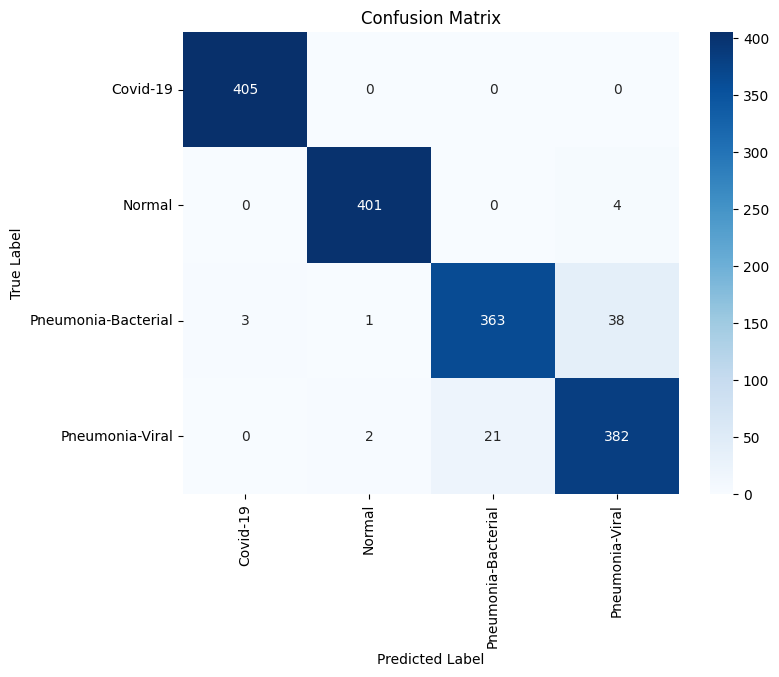

In [14]:
# Class names
class_names = test_dataset.classes   # automatically gets folder names

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [15]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd

from sklearn.metrics import (
    f1_score,
    accuracy_score
)

In [16]:
def ensemble_predict(
    images,
    w1,
    w2,
    boost
):

    # EfficientNet input
    img224 = images

    # Inception input
    img299 = F.interpolate(
        images,
        size=(299,299),
        mode='bilinear',
        align_corners=False
    )

    # Forward pass
    logits_eff = model_eff(img224)
    logits_inc = model_inc(img299)

    # Probabilities
    p_eff = torch.softmax(logits_eff, dim=1)
    p_inc = torch.softmax(logits_inc, dim=1)

    # Weighted fusion
    pfusion = (
        w1 * p_eff +
        w2 * p_inc
    )

    # Posterior class-aware boost
    boost = boost.unsqueeze(0)

    pboost = pfusion * boost

    # Renormalize
    pfinal = pboost / pboost.sum(
        dim=1,
        keepdim=True
    )

    return pfinal

In [17]:
def tta_predict(
    images,
    w1,
    w2,
    boost
):

    t1 = images

    t2 = torch.flip(
        images,
        dims=[3]
    )

    t3 = torch.clamp(
        images * 1.03,
        0,
        1
    )

    t4 = torch.clamp(
        images * 0.97,
        0,
        1
    )

    views = [t1,t2,t3,t4]

    outputs = []

    for v in views:

        out = ensemble_predict(
            v,
            w1,
            w2,
            boost
        )

        outputs.append(out)

    outputs = torch.stack(outputs)

    return outputs.mean(dim=0)

In [18]:
def evaluate_model(
    loader,
    w1,
    w2,
    boost,
    use_tta=True
):

    model_eff.eval()
    model_inc.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            if use_tta:

                outputs = tta_predict(
                    images,
                    w1,
                    w2,
                    boost
                )

            else:

                outputs = ensemble_predict(
                    images,
                    w1,
                    w2,
                    boost
                )

            preds = torch.argmax(
                outputs,
                dim=1
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average='macro'
    )

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    return macro_f1, accuracy

In [19]:
boost_tensor = torch.tensor(
    [1.0,1.0,1.6,1.6],
    device=device
)

f1_no_clahe, acc_no_clahe = evaluate_model(
    test_loader,
    w1=0.6,
    w2=0.4,
    boost=boost_tensor,
    use_tta=True
)

print("WITHOUT CLAHE")
print("Macro F1:", round(f1_no_clahe,4))
print("Accuracy:", round(acc_no_clahe,4))

WITHOUT CLAHE
Macro F1: 0.9582
Accuracy: 0.958


In [20]:
import random

In [21]:
def set_seed(seed):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False

In [23]:
SEEDS = [42,52,62,72,82]

boost_tensor = torch.tensor(
    [1.0,1.0,1.6,1.6],
    device=device
)

scores = []

for seed in SEEDS:

    set_seed(seed)

    f1, acc = evaluate_model(
        val_loader,
        w1=0.6,
        w2=0.4,
        boost=boost_tensor,
        use_tta=True
    )

    scores.append(f1)

mean_f1 = np.mean(scores)

std_f1 = np.std(scores)

print("WITHOUT CLAHE")
print(
    f"Val Macro F1 Mean ± SD: "
    f"{mean_f1:.4f} ± {std_f1:.4f}"
)

WITHOUT CLAHE
Val Macro F1 Mean ± SD: 0.9573 ± 0.0000


In [24]:
test_f1, test_acc = evaluate_model(
    test_loader,
    w1=0.6,
    w2=0.4,
    boost=boost_tensor,
    use_tta=True
)

print("Test Macro F1:", round(test_f1,4))
print("Test Accuracy:", round(test_acc,4))

Test Macro F1: 0.9582
Test Accuracy: 0.958
